In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

# ray 관련 라이브러리 임포트
import ray
from ray import tune
from ray.tune.registry import register_env

# 프로젝트 루트 디렉토리 설정
os.chdir("/home/youngjins/project/belief_trading")

# lib 하위 경로 추가
sys.path.append("/home/youngjins/project/belief_trading/lib/")
sys.path.append("/home/youngjins/project/belief_trading/lib/abides_jpmc_public")

# 환경 임포트
import gym
from abides_gym.envs.markets_execution_environment_v1 import (
    SubGymMarketsExecutionEnv_v1,
)

# lib 모듈 임포트
from lib.utils import gym_types, flatten_dict, history_dict
from lib.policy import PolicyTobinToCAPM, policyRandomWithNoAction

In [2]:
# 매개 변수 선언
seed = 0
np.random.seed(seed)

# window size 선언
state_window_size = 20
market_data_length = 10

# 환경 선언
gym_type_str = "markets-execution-v1"
gym_type_abb = gym_types[gym_type_str]
register_env(
    gym_type_str,
    lambda config: SubGymMarketsExecutionEnv_v1(**config),
)

# ray init
ray.shutdown()
ray.init()

2025-03-19 19:18:49,525	INFO worker.py:1752 -- Started a local Ray instance.


Python version:,3.8.0
Ray version:,2.10.0


In [3]:
# 강화학습 관련 변수 선언
env = gym.make(
    gym_type_str,
    background_config="rmsc04",
    timestep_duration="10S",
    execution_window="04:00:00",
    parent_order_size=5000,
    order_fixed_size=50,
    not_enough_reward_update=-100,  # penalty
    state_history_length=state_window_size,
    market_data_buffer_length=market_data_length,
    debug_mode=True,
)
env.seed(seed)

target_agent = PolicyTobinToCAPM(window_size=state_window_size)

In [4]:
# 시뮬레이션 시작
state = env.reset()
done = False
episode_reward = 0

# 1개 에피소드 실행 (소요 시간 측정)
start_time = time.time()
while not done:
    action_ = target_agent.get_action(state)
    env.direction = "BUY" if action_ > 0 else "SELL" if action_ < 0 else env.direction
    action = abs(action_)
    state, reward, done, info = env.step(action)
    episode_reward += reward

    # 현재 상태에서 필요한 정보 추출
    history_dict["mid_price"].append((info["best_bid"] + info["best_ask"]) / 2)
    history_dict["best_bid"].append(info["best_bid"])
    history_dict["best_ask"].append(info["best_ask"])
    history_dict["reward"].append(reward)
    history_dict["cumulative_reward"].append(episode_reward)
    history_dict["pnl"].append(info["pnl"])
    history_dict["holdings"].append(info["holdings"])
    history_dict["time"].append(info["current_time"])
    history_dict["action"].append(action_)
    history_dict["order_size"].append(env.parent_order_size)  # debuging
    history_dict["direction"].append(env.direction)  # debuging

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

# could add a few more...
output = flatten_dict(info)
output["episode_reward"] = episode_reward
output["name"] = target_agent.name

KeyboardInterrupt: 

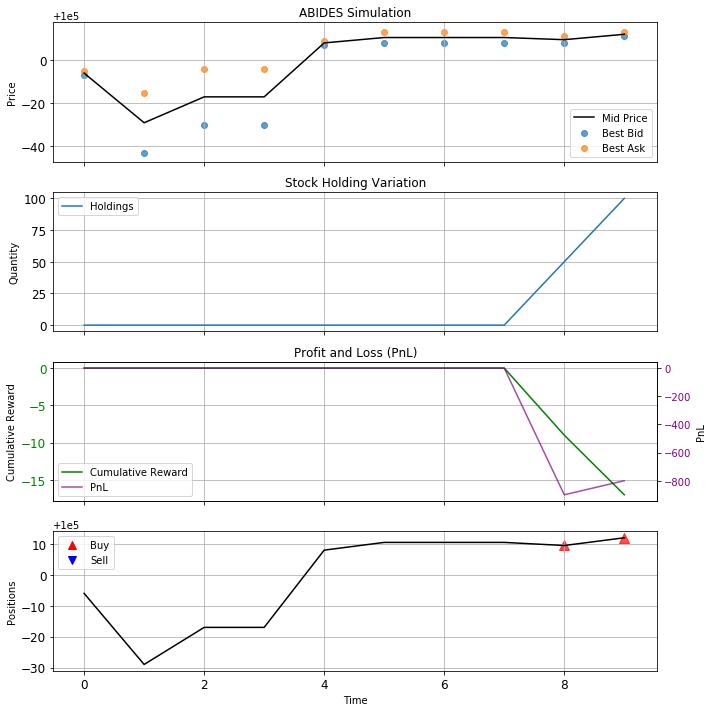

In [5]:
# 그래프 설정
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

# 폰트 사이즈 조정
font_size = 12
axes[0].tick_params(labelsize=font_size)
axes[1].tick_params(labelsize=font_size)
axes[2].tick_params(labelsize=font_size)
axes[3].tick_params(labelsize=font_size)

# 범례 폰트 사이즈 조정
legend_font_size = 10

# 1. 가격 변동 그래프
axes[0].plot(history_dict["mid_price"], label="Mid Price", color="black")
axes[0].scatter(
    range(len(history_dict["best_bid"])),
    history_dict["best_bid"],
    label="Best Bid",
    alpha=0.7,
)
axes[0].scatter(
    range(len(history_dict["best_ask"])),
    history_dict["best_ask"],
    label="Best Ask",
    alpha=0.7,
)
axes[0].set_title("ABIDES Simulation")
axes[0].set_ylabel("Price")
axes[0].legend()
axes[0].grid(True)

# 2. 보유량 그래프
axes[1].plot(history_dict["holdings"], label="Holdings")
axes[1].set_title("Stock Holding Variation")
axes[1].set_ylabel("Quantity")
axes[1].legend()
axes[1].grid(True)

# 3. 수익 그래프
# 왼쪽 y축은 Cumulative Reward용
axes[2].plot(
    history_dict["cumulative_reward"], label="Cumulative Reward", color="green"
)
axes[2].set_title("Profit and Loss (PnL)")
axes[2].set_ylabel("Cumulative Reward")
axes[2].tick_params(axis="y", labelcolor="green")
axes[2].grid(True)

# 오른쪽 y축은 PnL용
ax2 = axes[2].twinx()
ax2.plot(history_dict["pnl"], label="PnL", color="purple", alpha=0.7)
ax2.set_ylabel("PnL")
ax2.tick_params(axis="y", labelcolor="purple")

# 두 축의 범례를 하나로 합치기
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc="best")

# 4. 행동 그래프 (action > 0 이면 빨간색 위 방향 삼각형, action < 0 이면 파란색 아래 방향 삼각형)
# 행동 그래프를 첫 번째 가격 그래프에 추가
for i, action in enumerate(history_dict["action"]):
    if action > 0:  # 매수 행동
        axes[3].scatter(
            i, history_dict["mid_price"][i], marker="^", color="red", s=100, alpha=0.7
        )
    elif action < 0:  # 매도 행동
        axes[3].scatter(
            i, history_dict["mid_price"][i], marker="v", color="blue", s=100, alpha=0.7
        )

# 범례에 행동 표시 추가
custom_lines = [
    Line2D([0], [0], marker="^", color="red", linestyle="None", markersize=8),
    Line2D([0], [0], marker="v", color="blue", linestyle="None", markersize=8),
]
axes[3].plot(history_dict["mid_price"], label="Mid Price", color="black")
axes[3].legend(handles=custom_lines, labels=["Buy", "Sell"], fontsize=legend_font_size)
axes[3].set_xlabel("Time")
axes[3].grid(True)
axes[3].set_ylabel("Positions")

plt.tight_layout()
plt.show()